In [27]:
from pathlib import Path
import pandas as pd
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)
from src.profile_cluster_analysis import (
    load_behaviour_summary,
    make_daily_profile_matrix,
    evaluate_cluster_numbers,
    cluster_daily_profiles,
    summarize_clusters,
    calculate_cluster_homogeneity,
    add_distance_to_centroid,
    get_farthest_days,
    cluster_distribution_by_weekday,
    plot_average_daily_profile,
    plot_weekday_profiles,
    plot_cluster_profiles,
    plot_daily_profile_heatmap,
)

Project root added: c:\Data_analysis\Thesis


#### BU_TotActPwr_Tech_Room

In [ ]:
# target_col = "BU_TotActPwr_Tech_Room"
# freq = "15min"

# path = Path(
#     r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BU_TotActPwr_Tech_Room.parquet"
# )

# df = pd.read_parquet(path)

#### BU_TotActPwr_SDB_EL_Substation

In [ ]:
# target_col = "BU_TotActPwr_SDB_EL_Substation"
# freq = "15min"

# path = Path(
#     r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BU_TotActPwr_SDB_EL_Substation.parquet"
# )

# df = pd.read_parquet(path)

# print("Loaded dataframe shape:", df.shape)

#### BU_TotActPwr_Academy

In [ ]:
# target_col = "BU_TotActPwr_Academy"
# freq = "15min"

# path = Path(
#     r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BU_TotActPwr_Academy.parquet"
# )

# df = pd.read_parquet(path)

# print("Loaded dataframe shape:", df.shape)


Loaded dataframe shape: (19008, 39)
Index type: <class 'pandas.DatetimeIndex'>


#### BA_TotActPwr_BESS_AC_Panel1

In [ ]:
target_col = "BA_TotActPwr_BESS_AC_Panel1"
freq = "15min"

path = Path(
    r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BA_TotActPwr_BESS_AC_Panel1.parquet"
)

df = pd.read_parquet(path)

print("Loaded dataframe shape:", df.shape)

#### BA_TotActPwr_BESS_AC_Panel2

In [ ]:
# target_col = "BA_TotActPwr_BESS_AC_Panel2"
# freq = "15min"

# path = Path(
#     r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BA_TotActPwr_BESS_AC_Panel2.parquet"
# )

# df = pd.read_parquet(path)

# print("Loaded dataframe shape:", df.shape)

### load behaviour summary

In [29]:
summary_df = load_behaviour_summary(
    df=df,
    target_col=target_col,
)

display(summary_df)

,target_col,n_samples,mean,median,std,min,max,q25,q75,q90,q95,coefficient_of_variation,zero_or_near_zero_%,low_load_%,high_load_%,low_load_threshold,high_load_threshold
0,BU_TotActPwr_Academy,17131,8.212527,5.17233,6.834286,0.0,64.126,3.76467,11.17933,16.764,20.50033,0.832178,0.005837,25.013134,10.005254,3.76467,16.764


### Plot average profiles

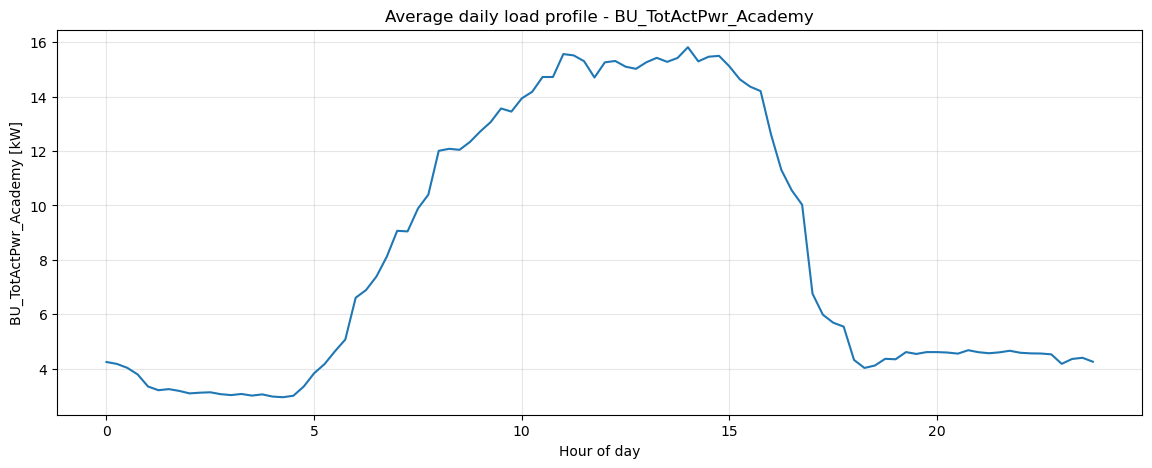

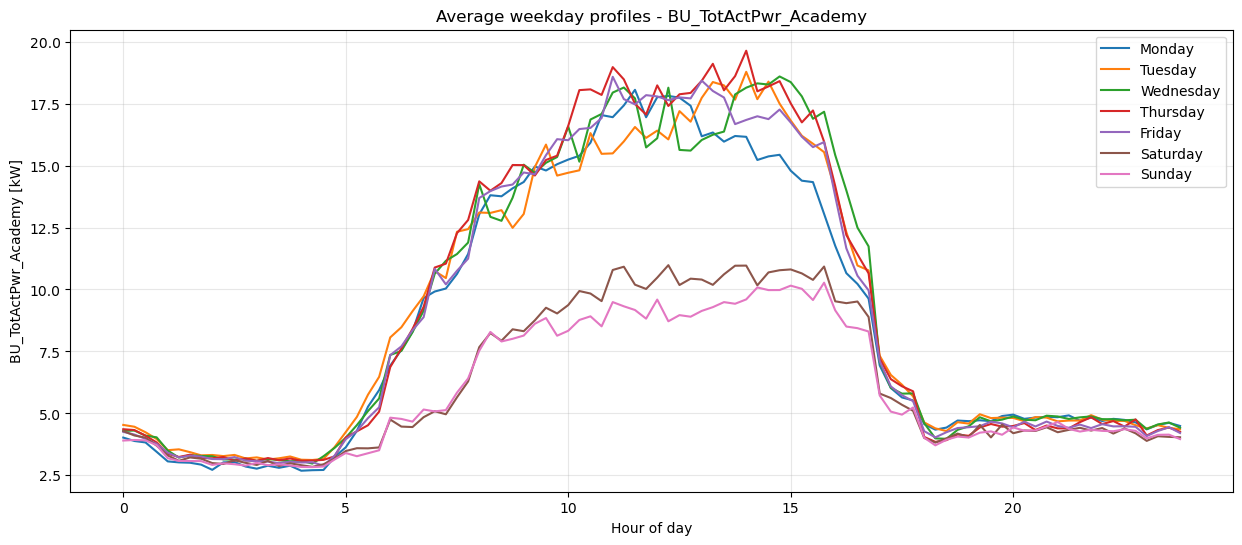

In [30]:
plot_average_daily_profile(df, target_col)
plot_weekday_profiles(df, target_col)

### Make daily profile matrix

In [31]:
daily_profiles = make_daily_profile_matrix(
    df=df,
    target_col=target_col,
    freq=freq,
    min_daily_coverage=0.90,
)

print("Daily profile matrix shape:", daily_profiles.shape)
display(daily_profiles.head())

Daily profile matrix shape: (173, 48)


,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
2025-10-15,3.715170,4.027500,3.285835,2.298500,2.447835,2.507000,2.867170,2.840000,2.484665,2.841165,...,3.425665,4.344665,4.658000,4.405665,4.097500,4.417835,4.590500,4.158000,4.195500,4.390500
2025-10-16,3.758000,3.924835,3.398165,2.542500,2.559670,2.682830,2.495665,2.358665,2.885670,2.550835,...,3.191500,4.220500,4.737335,4.280000,4.330335,4.285165,4.201835,4.602330,4.144835,4.309330
2025-10-17,4.160835,3.845000,3.889835,2.576670,2.630335,2.664165,3.162835,2.377670,2.517830,2.396500,...,4.766665,5.150835,3.793000,4.252170,4.128500,4.206500,3.934500,4.025500,3.831330,3.734665
2025-10-18,4.286000,4.488670,3.268165,2.505665,2.464165,2.673335,2.752835,2.408000,2.545500,2.677830,...,3.345670,3.832830,4.001500,4.192665,4.125835,4.337330,4.383665,3.727165,3.791500,3.941000
2025-10-19,3.882335,4.494335,3.552500,2.468835,2.569835,2.939500,2.550000,2.654335,2.603000,2.949500,...,3.505000,3.828835,4.145500,4.190665,3.968000,4.059000,4.188165,3.992835,3.960330,3.984170


### Check silhouette score

In [32]:
cluster_scores = evaluate_cluster_numbers(
    daily_profiles=daily_profiles,
    cluster_range=range(2, 8),
)

display(cluster_scores)

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packag

,n_clusters,silhouette_score
0,2,0.712596
1,3,0.221917
2,4,0.232886
3,5,0.209212
4,6,0.195302
5,7,0.177468


### Run final clustering

In [33]:
n_clusters = 4

clustered_profiles, cluster_model, profile_scaler = cluster_daily_profiles(
    daily_profiles=daily_profiles,
    n_clusters=n_clusters,
)

display(
    clustered_profiles[
        ["date", "dayofweek", "is_weekend", "pattern_cluster"]
    ].head()
)

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,date,dayofweek,is_weekend,pattern_cluster
2025-10-15,2025-10-15,Wednesday,0,1
2025-10-16,2025-10-16,Thursday,0,1
2025-10-17,2025-10-17,Friday,0,1
2025-10-18,2025-10-18,Saturday,1,1
2025-10-19,2025-10-19,Sunday,1,1


### Cluster summary

In [34]:
cluster_summary = summarize_clusters(
    clustered_profiles=clustered_profiles,
    freq=freq,
)

display(cluster_summary)

,pattern_cluster,n_days,mean_load_kW,median_load_kW,max_load_kW,std_load_kW,daily_energy_kWh_mean,daily_energy_kWh_median,daily_energy_kWh_std,daily_energy_kWh_cv
0,0,53,9.927119,5.720835,44.954670,7.568841,238.250856,232.389250,39.575929,0.166110
1,1,86,6.342581,4.471585,19.983170,3.837693,152.221944,160.970583,31.227947,0.205147
2,2,4,21.444501,9.613333,62.747500,19.551336,514.668022,512.681109,99.183628,0.192714
3,3,30,8.597445,6.298915,26.051835,5.240016,206.338676,205.514207,33.460114,0.162161


### Homogeneity check

In [35]:
homogeneity_summary = calculate_cluster_homogeneity(
    clustered_profiles=clustered_profiles,
    freq=freq,
)

display(homogeneity_summary)

,pattern_cluster,n_days,mean_distance_to_centroid,median_distance_to_centroid,max_distance_to_centroid,mean_profile_std_kW,max_profile_std_kW,daily_energy_kWh_mean,daily_energy_kWh_std,daily_energy_kWh_cv
0,0,53,20.523082,17.821093,54.682409,2.537971,6.313534,238.250856,39.200793,0.164536
1,1,86,14.425808,13.116685,28.188298,1.774796,3.818537,152.221944,31.045859,0.203951
2,2,4,66.001976,66.028209,72.033832,6.732493,22.921435,514.668022,85.895541,0.166895
3,3,30,16.050095,14.216784,34.546940,2.038840,4.261740,206.338676,32.897719,0.159436


| Column                        | Meaning                                             |
| ----------------------------- | --------------------------------------------------- |
| `mean_distance_to_centroid`   | Average distance of days from cluster average shape |
| `median_distance_to_centroid` | Typical distance from centroid                      |
| `max_distance_to_centroid`    | Most unusual day inside cluster                     |
| `mean_profile_std_kW`         | Average profile spread inside cluster               |
| `daily_energy_kWh_cv`         | Energy variability inside cluster                   |


### Find unusual days inside each cluster

In [36]:
clustered_profiles_with_distance = add_distance_to_centroid(
    clustered_profiles=clustered_profiles,
)

farthest_days = get_farthest_days(
    clustered_profiles_with_distance=clustered_profiles_with_distance,
    top_n=5,
)

display(farthest_days)

,date,dayofweek,is_weekend,pattern_cluster,distance_to_cluster_centroid
0,2026-04-09,Thursday,0,0,54.682409
1,2026-04-10,Friday,0,0,50.101343
2,2026-04-02,Thursday,0,0,41.430557
3,2026-03-14,Saturday,1,0,40.495754
4,2026-02-02,Monday,0,0,35.155233
5,2025-11-26,Wednesday,0,1,28.188298
6,2026-01-10,Saturday,1,1,26.286202
7,2025-11-27,Thursday,0,1,25.651206
8,2025-11-09,Sunday,1,1,25.398128
9,2026-01-31,Saturday,1,1,24.625117


### Weekday distribution

In [37]:
weekday_cluster_table = cluster_distribution_by_weekday(
    clustered_profiles=clustered_profiles,
)

display(weekday_cluster_table)

pattern_cluster,0,1,2,3
dayofweek,,,,
Monday,31.82,40.91,0.00,27.27
Tuesday,44.00,28.00,4.00,24.00
Wednesday,37.04,37.04,3.70,22.22
Thursday,38.46,46.15,3.85,11.54
Friday,40.00,36.00,4.00,20.00
Saturday,12.50,79.17,0.00,8.33
Sunday,8.33,83.33,0.00,8.33


### Final plots

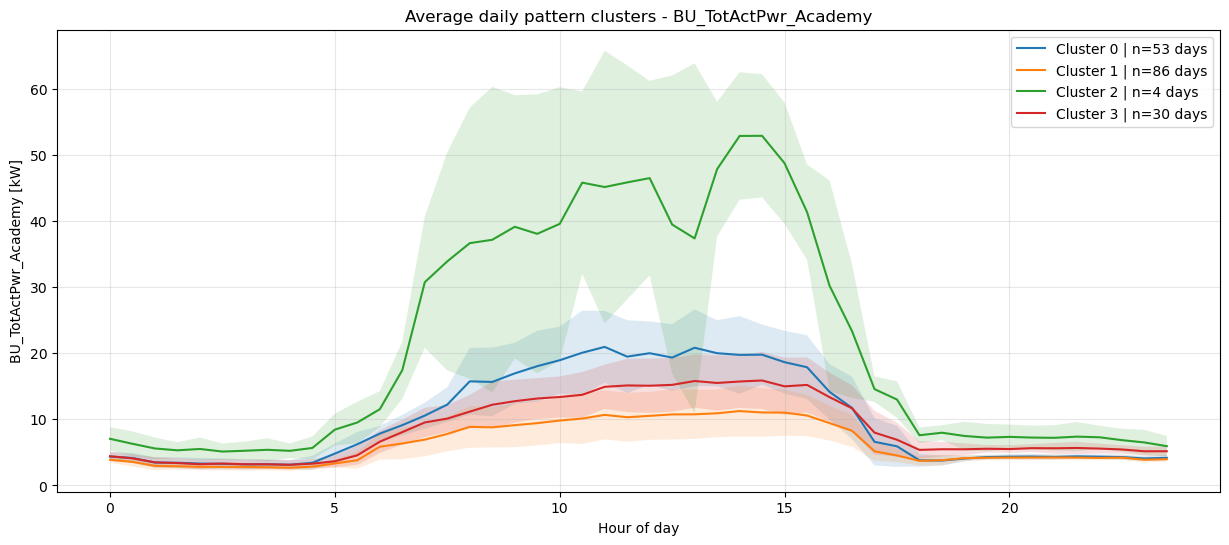

In [38]:
plot_cluster_profiles(
    clustered_profiles=clustered_profiles,
    target_col=target_col,
    freq=freq,
    show_std_band=True,
)